<a href="https://colab.research.google.com/github/sricharithathatavarthi/heart/blob/main/heart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

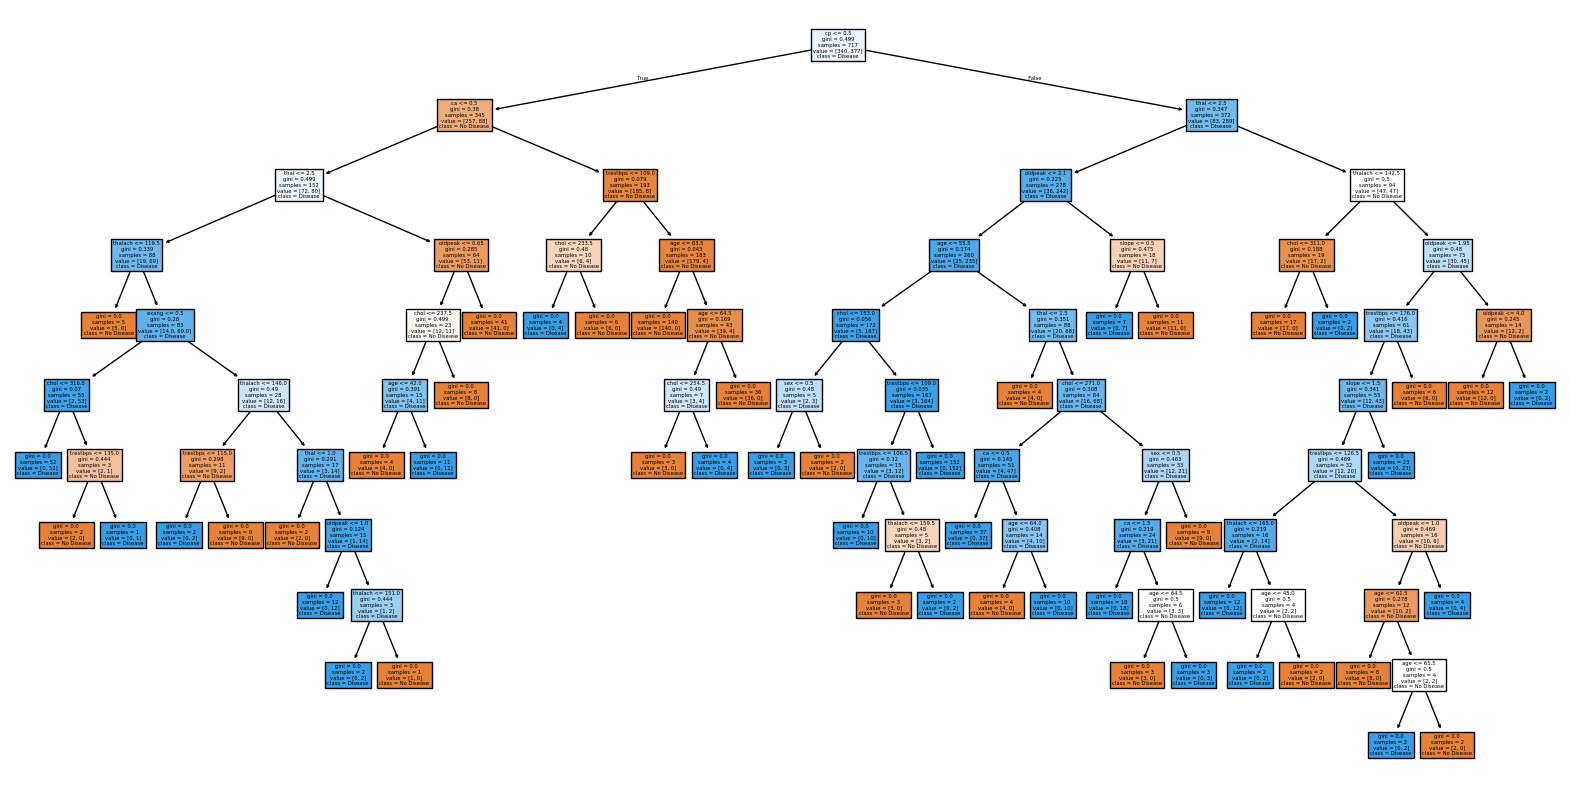

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Load dataset
heart = pd.read_csv("heart.csv")
X = heart.drop("target", axis=1)
y = heart["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Decision Tree
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Visualize tree
plt.figure(figsize=(20,10))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=["No Disease","Disease"])
plt.show()


In [2]:
# Train with max_depth=3
clf_depth = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_depth.fit(X_train, y_train)

print("Train Accuracy:", clf_depth.score(X_train, y_train))
print("Test Accuracy:", clf_depth.score(X_test, y_test))


Train Accuracy: 0.8577405857740585
Test Accuracy: 0.8051948051948052


In [3]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Decision Tree Accuracy:", clf_depth.score(X_test, y_test))
print("Random Forest Accuracy:", rf.score(X_test, y_test))


Decision Tree Accuracy: 0.8051948051948052
Random Forest Accuracy: 0.9805194805194806


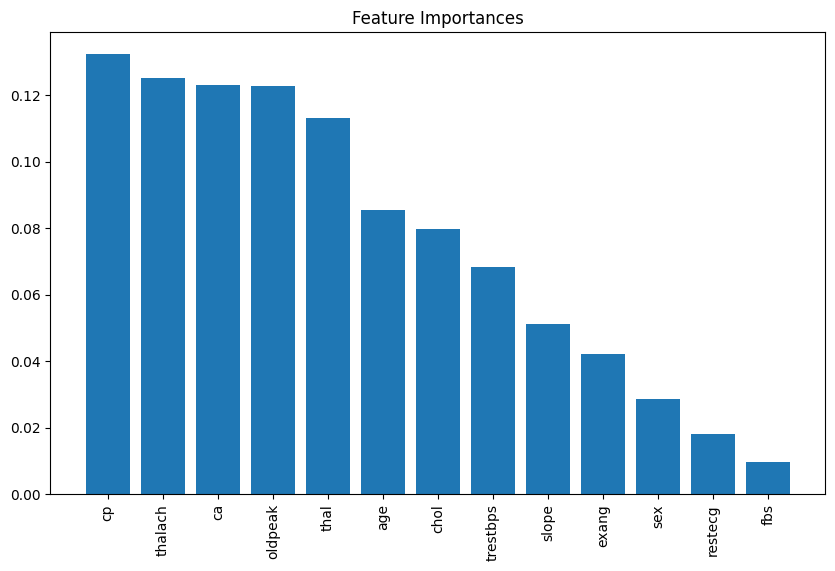

In [4]:
import numpy as np

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.title("Feature Importances")
plt.show()


In [5]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Cross-validation scores: [1.         1.         1.         1.         0.98536585]
Mean CV Accuracy: 0.9970731707317073
